In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Adiciona a pasta raiz ao path para que o Jupyter encontre o pacote 'src'
sys.path.append(os.path.abspath(os.path.join('..')))

from src.routing.vehicle import Vehicle
from src.tsp.genetic_algorithm import run_genetic_algorithm
from src.visualization.map_routes import plotar_mapa_inline, atualizar_tela_evolucao
from src.llm.report_generator import ReportGenerator

print("Módulos carregados com sucesso!")

pygame-ce 2.5.7 (SDL 2.32.10, Python 3.12.10)
Módulos carregados com sucesso!


In [2]:
def plotar_evolucao(historico_fitness):
    plt.figure(figsize=(10, 5))
    plt.plot(historico_fitness, color='blue', linewidth=2)
    plt.title("Evolução do Algoritmo Genético (Projeto 2 - FIAP)")
    plt.xlabel("Geração")
    plt.ylabel("Custo (Distância + Penalidades)")
    plt.grid(True)
    plt.show()

A iniciar otimização para o veículo: MINI_01
------------------------------
Otimização finalizada. Custo: 95690.03


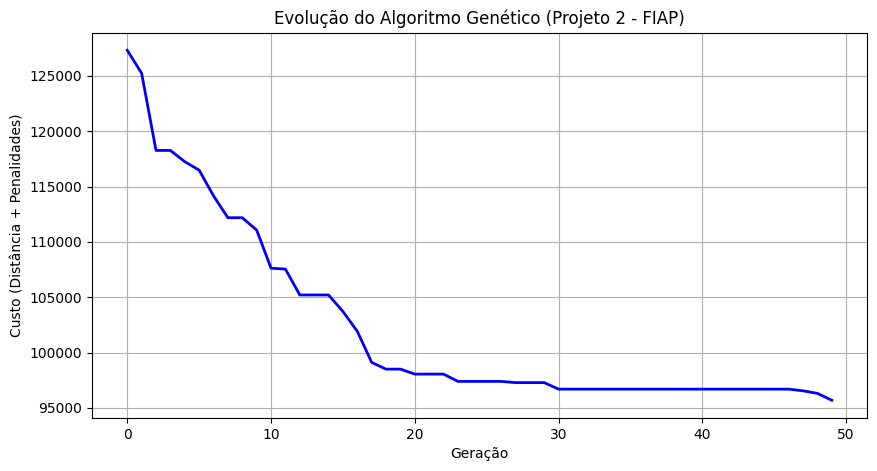

Gerando visualização estática final...


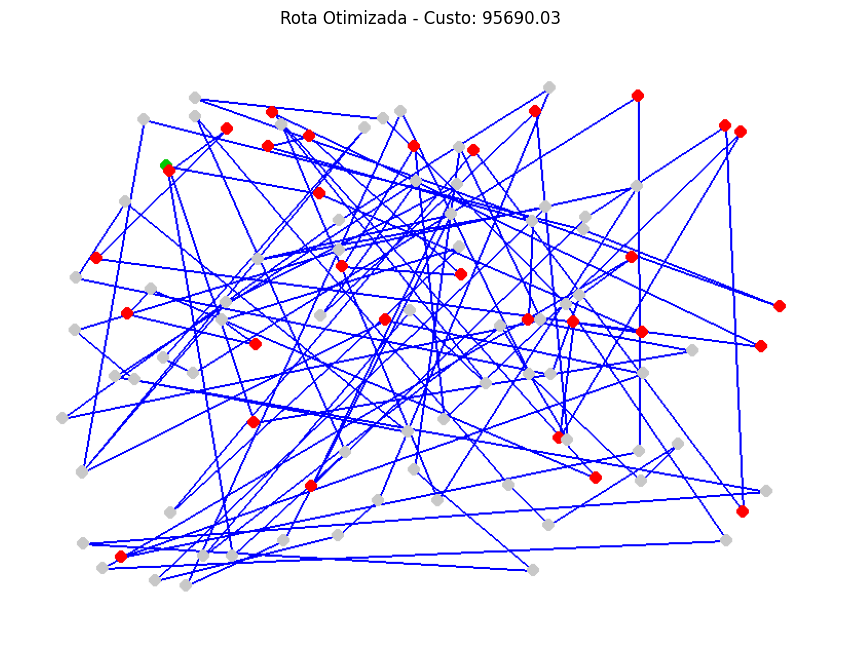

------------------------------
Melhor rota encontrada: [np.int64(80), np.int64(69), np.int64(99), np.int64(44), np.int64(17), np.int64(13), np.int64(19), np.int64(48), np.int64(68), np.int64(53)]... (Total: 99 pontos)
Custo total da operação: 95690.03 Km


In [3]:
# 1. Carregar os destinos
df_destinos = pd.read_csv('data/destinos.csv')

# 2. Criar um veículo (ex: Mini Camião)
# ID, Tipo, Capacidade, Autonomia, Custo/Km
mini_truck = Vehicle('MINI_01', 'mini', 200, 400, 2.5)

print(f"A iniciar otimização para o veículo: {mini_truck.id}")
print("-" * 30)

# 3. Executar o Algoritmo Genético
# Vamos usar uma população menor para o teste ser rápido
melhor_rota, melhor_custo, historico_fitness = run_genetic_algorithm(
    df_destinos, 
    mini_truck, 
    pop_size=20, 
    generations=50
)

# 2. Quando o Pygame fechar, ele mostrará o gráfico de desempenho
print(f"Otimização finalizada. Custo: {melhor_custo:.2f}")
plotar_evolucao(historico_fitness)

# 3. Plota o Mapa Final DIRETAMENTE no Jupyter
print("Gerando visualização estática final...")
plotar_mapa_inline(df_destinos, melhor_rota, titulo=f"Rota Otimizada - Custo: {melhor_custo:.2f}")

print("-" * 30)
print(f"Melhor rota encontrada: {melhor_rota[:10]}... (Total: {len(melhor_rota)} pontos)")
print(f"Custo total da operação: {melhor_custo:.2f} Km")

In [4]:
import os
from dotenv import load_dotenv

# Carrega as variáveis do arquivo .env
load_dotenv()

# Busca a chave de forma segura
minha_chave = os.getenv("GEMINI_API_KEY")

if minha_chave:
    print("✅ Chave carregada com sucesso do ambiente!")
else:
    print("❌ Erro: Chave não encontrada no arquivo .env")

✅ Chave carregada com sucesso do ambiente!


In [5]:
report_bot = ReportGenerator(api_key=minha_chave)
resumo = report_bot.formatar_dados_rota(melhor_rota, df_destinos, mini_truck, melhor_custo)

print("Gerando relatório final (v1 estável)...")
relatorio = report_bot.gerar_relatorio_ia(resumo)

from IPython.display import Markdown, display
display(Markdown(relatorio))

Gerando relatório final (v1 estável)...


# Relatório de Análise Operacional - Rota Hospitalar

## Dados da Operação

*   **Veículo:** MINI_01 (mini)
*   **Autonomia Nominal do Veículo (Estimada):** 400km
*   **Autonomia Utilizada Registrada:** 95690.03km
*   **Carga Total:** 626.00kg
*   **Paradas:** 99 (69 Hospitais, 30 Residências)
*   **Nível de Prioridade:** 30 pontos de alta urgência atendidos

---

## 1. Análise de Eficiência (Combustível vs Carga)

### 1.1. Autonomia Utilizada: Discrepância Crítica

A informação de "Autonomia Utilizada: 95690.03km / 400km" apresenta uma **discrepância crítica e inviável** para uma única operação logística de um veículo.

*   **Interpretação Mais Provável:** Este dado quase certamente indica um **erro de registro ou agregação**. Um veículo com autonomia nominal de 400km não poderia percorrer 95.690,03km em uma única rota sem múltiplos e sucessivos reabastecimentos/recargas, o que descaracterizaria a "autonomia utilizada" como uma métrica de eficiência para *aquela* rota específica.
*   **Se Considerado Literalmente (e Erroneamente):** Se essa fosse a distância *real* percorrida para *uma única rota*, a ineficiência seria catastrófica, com o veículo tendo que ser reabastecido/recarregado aproximadamente 239 vezes (95690.03km / 400km), o que é logística e operacionalmente impossível para uma rota.
*   **Recomendação Urgente:** É imperativo **verificar a integridade e a metodologia de registro** dos dados de autonomia utilizada. Sem dados precisos, qualquer análise de eficiência de combustível é comprometida. Presume-se que a autonomia utilizada real para esta *rota* específica deveria ser comparável (inferior ou ligeiramente superior) à autonomia nominal.

### 1.2. Carga vs. Capacidade do Veículo

*   **Análise:** Para um veículo classificado como "mini", uma carga de **626.00kg é extremamente elevada e provavelmente excede, ou está no limite máximo**, da sua capacidade de carga útil (PBT - Peso Bruto Total). Veículos "mini" geralmente têm capacidade de carga útil que varia de 300kg a 500kg, dependendo do modelo.
*   **Implicações:**
    *   **Aumento Drástico do Consumo:** Operar um veículo sobrecarregado ou no limite da sua capacidade resulta em um aumento significativo no consumo de combustível (ou energia), pois o motor precisa trabalhar mais arduamente.
    *   **Desgaste Acelerado:** Componentes como suspensão, freios, pneus e o próprio motor e transmissão sofrem um desgaste muito mais rápido, aumentando os custos de manutenção e o risco de falhas mecânicas.
    *   **Comprometimento da Segurança e Dirigibilidade:** Um veículo sobrecarregado tem sua estabilidade, capacidade de frenagem e manobrabilidade seriamente comprometidas, aumentando o risco de acidentes.

### 1.3. Impacto Geral na Eficiência Operacional

Mesmo desconsiderando a anomalia dos dados de autonomia, a operação descrita demonstra um perfil de alta demanda e potencial ineficiência:

*   **Número de Paradas:** 99 paradas para entrega (69 hospitais + 30 residências) implicam em um ciclo constante de aceleração, desaceleração e frenagem. Isso, por si só, é um grande fator de aumento do consumo de combustível e desgaste para qualquer veículo, especialmente para um "mini" que não foi projetado para tal rigor.
*   **Pontos de Urgência:** Atender 30 pontos de alta urgência pode levar o motorista a operar o veículo de forma mais agressiva (acelerações e frenagens mais fortes) para cumprir prazos, impactando negativamente a eficiência de combustível e o desgaste.

---

## 2. Recomendações de Segurança para o Motorista

Dado o perfil da rota (alta carga para o veículo, numerosas paradas, pontos de alta urgência), as seguintes recomendações de segurança são cruciais para o motorista do MINI_01:

### 2.1. Controle de Fadiga e Descanso

*   **Pausas Obrigatórias:** Com 99 paradas, a demanda mental e física é enorme. Assegurar que o motorista faça pausas regulares e obrigatórias, conforme a legislação e políticas internas, para evitar a fadiga.
*   **Monitoramento de Jornada:** Monitorar estritamente a jornada de trabalho para garantir que os tempos de condução e descanso sejam respeitados, prevenindo o sono ao volante.

### 2.2. Segurança e Distribuição da Carga

*   **Amarração e Estabilidade:** É fundamental que a carga de 626kg esteja perfeitamente distribuída e firmemente amarrada dentro do compartimento do veículo. Carga mal acomodada pode se deslocar, alterando o centro de gravidade e comprometendo severamente a estabilidade, especialmente em curvas ou frenagens.
*   **Limites de Peso:** O motorista deve ser treinado para reconhecer os limites de peso do veículo e não aceitar cargas que excedam a capacidade segura, mesmo sob pressão de urgência.

### 2.3. Condução Defensiva

*   **Antecipação e Calma:** A alta urgência em 30 pontos não deve comprometer a segurança. O motorista deve ser instruído a manter uma condução defensiva, antecipando riscos e evitando manobras bruscas, que são ainda mais perigosas com um veículo pesado e potencialmente sobrecarregado.
*   **Respeito aos Limites:** Sempre respeitar os limites de velocidade e as condições da via, lembrando que a capacidade de frenagem e manobra do veículo está comprometida pela carga.

### 2.4. Comunicação e Suporte

*   **Canais de Comunicação:** Manter canais de comunicação abertos e eficientes com a central de operações para que o motorista possa reportar qualquer incidente, problema mecânico ou situação de emergência imediatamente.
*   **Treinamento para Emergências:** Fornecer treinamento e equipamentos (kit de primeiros socorros, triângulo, colete refletivo) para lidar com situações de emergência na estrada.

### 2.5. Verificação Pré-Viagem e Manutenção

*   **Checklist Rigoroso:** Dada a carga e o número de paradas, um checklist pré-viagem rigoroso é essencial: pneus (pressão e desgaste), freios, suspensão, níveis de fluidos e funcionamento de luzes.
*   **Manutenção Preventiva:** Implementar um plano de manutenção preventiva mais frequente para o veículo, devido ao estresse operacional a que é submetido. Qualquer anomalia deve ser reportada e resolvida antes da próxima saída.

---

**Conclusão Geral:** A rota analisada, conforme os dados apresentados, revela uma operação de alta complexidade e potencial ineficiência para o veículo utilizado, com sérias implicações de segurança e desgaste do equipamento. A revisão da integridade dos dados e a adequação do veículo à carga e ao perfil da rota são prioridades.